In [12]:
import pandas as pd
from datetime import datetime as dt,timedelta
import plotly.express as px
import plotly.graph_objects as go
import plotly.colors

In [5]:
data=pd.read_csv("C:\\Users\\lenovo\\Downloads\\online_retail.csv\\online_retail.csv")
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
data.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [7]:
data.dropna(subset=['CustomerID'],inplace=True)

In [8]:
data['InvoiceDate']=pd.to_datetime(data['InvoiceDate'])
data['TotalAmount']=data['Quantity']*data['UnitPrice']


In [9]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [10]:
refrance_date=pd.Timestamp(dt.now().date())

AttributeError: module 'datetime' has no attribute 'now'

In [13]:
refrance_date = data['InvoiceDate'].max() + timedelta(days=1)

In [14]:
refrance_date

Timestamp('2011-12-10 12:50:00')

In [18]:
rfm = data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (refrance_date - x.max()).days,
    'InvoiceNo':'count',
    'TotalAmount':'sum'
})

In [21]:
rfm.rename(columns={
    'InvoiceDate':'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'}, inplace=True
)

In [22]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [36]:
quantiles=rfm.quantile(q=[0.25,0.5,0.75])
def r_score(x,p,d):
    if p =='Recency':
        if x<=d[p] [0.25]:
            return 4
        elif x <= d[p] [0.5]:
            return 3
        elif  x<=d[p] [0.75]:
            return 2 
        else:
            return 1
    else:
        if x<=d[p] [0.25]:
                return 1
        elif  x<=d[p] [0.5]:
                return 2
        elif x<=d[p] [0.75]:
                return 3
        else:
            return 4
            
        
rfm['R'] = rfm['Recency'].apply(r_score,args=('Recency',quantiles,))
rfm['F'] = rfm['Frequency'].apply(r_score,args=('Frequency',quantiles,))
rfm['M'] = rfm['Monetary'].apply(r_score,args=('Monetary',quantiles))

    



In [37]:
rfm.head()

,Recency,Frequency,Monetary,R,F,M
CustomerID,,,,,,
12346.0,326,2,0.00,1,1,1
12347.0,2,182,4310.00,4,4,4
12348.0,75,31,1797.24,2,2,4
12349.0,19,73,1757.55,3,3,4
12350.0,310,17,334.40,1,1,2


In [39]:
rfm['RFM_Segment'] =rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)
rfm['RFM_Score'] = rfm[['R','F','M']].sum(axis=1)

In [40]:
rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM_Segment,RFM_Score
CustomerID,,,,,,,,
12346.0,326,2,0.00,1,1,1,111,3
12347.0,2,182,4310.00,4,4,4,444,12
12348.0,75,31,1797.24,2,2,4,224,8
12349.0,19,73,1757.55,3,3,4,334,10
12350.0,310,17,334.40,1,1,2,112,4


In [47]:
segment_label = ['Low-value','High-value','Mid-value']

def assin_segment(score):
    if score < 5:
        return 'Low-value'
    elif score < 9:
        return 'Mid-value'
    else:
        return 'High-value'

rfm['RFM_segment_label'] = rfm['RFM_Score'].apply(assin_segment)

rfm.head()


,Recency,Frequency,Monetary,R,F,M,RFM_Segment,RFM_Score,RFM_segment_label
CustomerID,,,,,,,,,
12346.0,326,2,0.00,1,1,1,111,3,Low-value
12347.0,2,182,4310.00,4,4,4,444,12,High-value
12348.0,75,31,1797.24,2,2,4,224,8,Mid-value
12349.0,19,73,1757.55,3,3,4,334,10,High-value
12350.0,310,17,334.40,1,1,2,112,4,Low-value


In [50]:
fig = px.histogram(rfm, x='Recency', nbins=30, title='Recency Distribution (days)')
fig.update_traces(marker_color='skyblue')
fig.show()

fig = px.histogram(rfm, x='Frequency', nbins=30, title='Frequency Distribution')
fig.update_traces(marker_color='lightgreen')
fig.show()

fig = px.histogram(rfm, x='Monetary', nbins=30, title='Monetary Distribution')
fig.update_traces(marker_color='salmon')
fig.show()

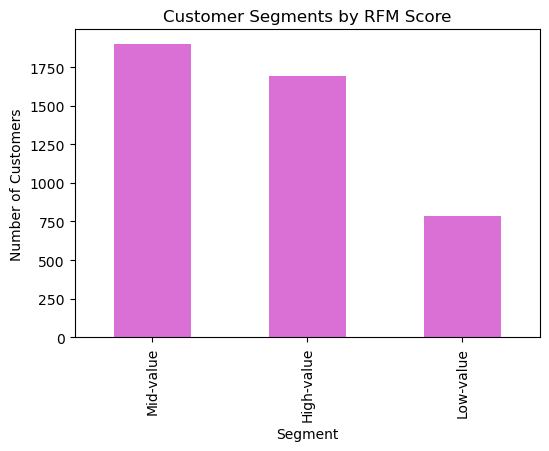

In [52]:
rfm['RFM_segment_label'].value_counts().plot(kind='bar', color='orchid', figsize=(6,4))
plt.title('Customer Segments by RFM Score')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.show()


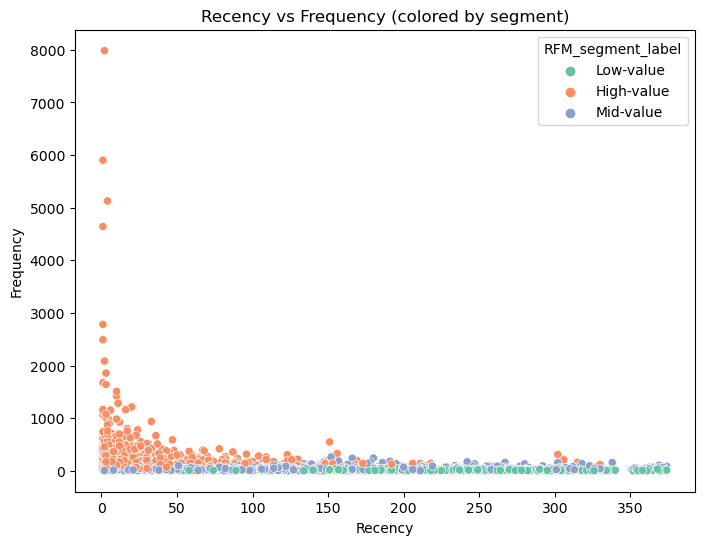

In [53]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x='Recency', y='Frequency', hue='RFM_segment_label', palette='Set2')
plt.title('Recency vs Frequency (colored by segment)')
plt.show()


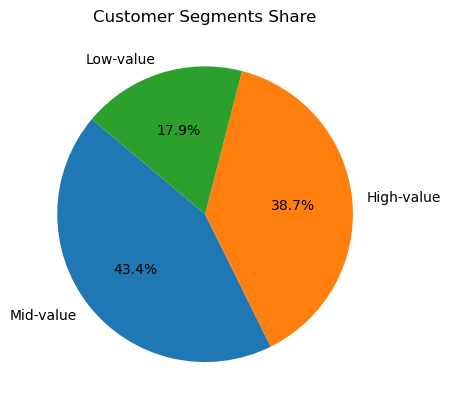

In [54]:
rfm['RFM_segment_label'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.ylabel('')
plt.title('Customer Segments Share')
plt.show()
